# Preprocessing for Machine Learning: Credit Score Classification
#### Mohamed Saleh Abdelsalam - 233656 - AI

### Content
     1. Data Overview
     2. Data Preprocessing
        2.1 Drop Unnecessary Columns
        2.2 Change to Correct Datatypes
        2.3 Data Distribution
        2.4 Handling Outliers
        2.5 Handling Nulls
    3. Data Cleaning Results
    4. Data Encoding

## 1. Data Overview
Over the years, a global finance company has collected basic bank details and gathered anonymized credit-related information that the dataset represents. Each record corresponds to a single customer’s financial and demographic profile for a given month, with the goal of predicting their credit score category (Good, Standard, or Poor). This problem falls under the supervised machine learning classification domain, where the target variable is Credit_Score.

<b>URL:</b> https://www.kaggle.com/datasets/parisrohan/credit-score-classification/data?select=train.csv

Import all important libraries.

In [204]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder ,StandardScaler , PolynomialFeatures , MinMaxScaler
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.ensemble import VotingClassifier , BaggingClassifier , RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 2. Data Preprocessing

Load dataset using pandas

In [205]:
path=r"C:\Users\Mohamed Saleh\Documents\Documents\Computer Science\Artificial Intelligence\Semester 7\Machine Learning\Assignment 1\233656_Classification\CreditScore Dataset\train.csv"
df=pd.read_csv(path)
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.00,_,809.98,26.82,22 Years and 1 Months,No,49.57,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.00,Good,809.98,31.94,NaN,No,49.57,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.00,Good,809.98,28.61,22 Years and 3 Months,No,49.57,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.00,Good,809.98,31.38,22 Years and 4 Months,No,49.57,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.00,Good,809.98,24.80,22 Years and 5 Months,No,49.57,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,"3,359.42",4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.00,_,502.38,34.66,31 Years and 6 Months,No,35.10,60.97133255718485,High_spent_Large_value_payments,479.87,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,"3,359.42",4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.00,_,502.38,40.57,31 Years and 7 Months,No,35.10,54.18595028760385,High_spent_Medium_value_payments,496.65,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,"3,359.42",4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.00,Good,502.38,41.26,31 Years and 8 Months,No,35.10,24.02847744864441,High_spent_Large_value_payments,516.81,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,"3,359.42",4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.00,Good,502.38,33.64,31 Years and 9 Months,No,35.10,251.67258219721603,Low_spent_Large_value_payments,319.16,Standard


Get information to understand the data more.

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Check percentange of missing values and visualization.

In [207]:
df.isnull().mean()*100

ID                          0.00
Customer_ID                 0.00
Month                       0.00
Name                        9.98
Age                         0.00
SSN                         0.00
Occupation                  0.00
Annual_Income               0.00
Monthly_Inhand_Salary      15.00
Num_Bank_Accounts           0.00
Num_Credit_Card             0.00
Interest_Rate               0.00
Num_of_Loan                 0.00
Type_of_Loan               11.41
Delay_from_due_date         0.00
Num_of_Delayed_Payment      7.00
Changed_Credit_Limit        0.00
Num_Credit_Inquiries        1.97
Credit_Mix                  0.00
Outstanding_Debt            0.00
Credit_Utilization_Ratio    0.00
Credit_History_Age          9.03
Payment_of_Min_Amount       0.00
Total_EMI_per_month         0.00
Amount_invested_monthly     4.48
Payment_Behaviour           0.00
Monthly_Balance             1.20
Credit_Score                0.00
dtype: float64

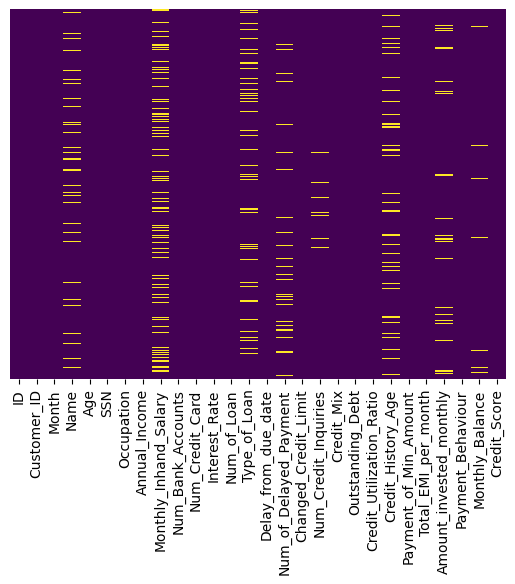

In [208]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
plt.show()

Check for duplicates.

In [209]:
df.duplicated().sum() #No duplicates

np.int64(0)

### 2.1 Drop Unnecessary Columns

<ul>
<li>ID, CustomerID, and SSN: Just identification numbers with no classification importance.</li>
<li>Name: Textual data and will not matter for classification.</li>
<li>Month: The season doesn't affect credit score.</li>
<li>Type of loan: the column has multiple loans(multiple categories) in each row.</li>
</ul>


In [210]:
df.drop(['ID', 'Customer_ID','Name', 'SSN', 'Month','Type_of_Loan'], axis=1 , inplace=True)

In [211]:
df.shape

(100000, 22)

### 2.2 Change to the correct data types. 

from object to numerical.

In [212]:
df.dtypes

Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [213]:
# Convert columns with numeric strings to float
numerical = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary",
    "Num_Bank_Accounts", "Num_Credit_Card",
    "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
    "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Total_EMI_per_month",
    "Amount_invested_monthly", "Monthly_Balance",
    "Credit_History_Age"
]

for col in numerical:
    if df[col].dtype == 'object':
        # Remove underscores before extracting numbers
        df[col] = df[col].str.replace('_', '', regex=False)

        # Extract numeric part
        df[col] = df[col].str.extract(r'(\d+)')

        # Convert to float
        df[col] = pd.to_numeric(df[col], errors='coerce')


Repair Age Column
-> Some rows age reaches 500 or 8000 which in not realistic

<Axes: xlabel='Age', ylabel='Density'>

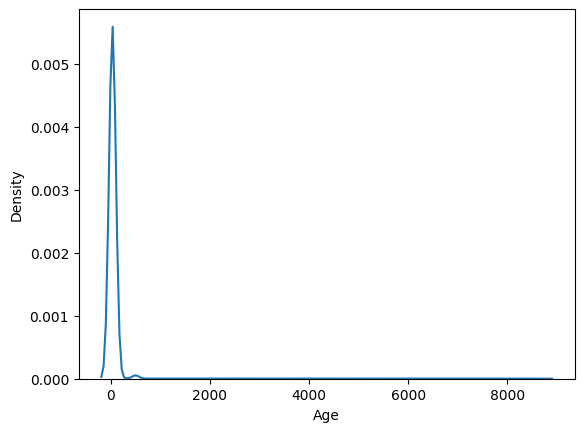

In [214]:
sns.kdeplot(df['Age'])

Drop rows where age > 85

In [215]:
df.drop(df[df['Age']>85].index , axis=0 , inplace=True)

<Axes: xlabel='Age', ylabel='Density'>

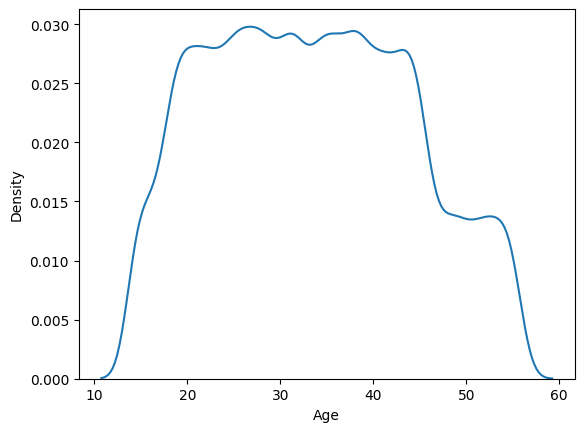

In [216]:
sns.kdeplot(df['Age'])

### 2.3 Data Distribution

In [217]:
def visualize_distribution(data, numeric_cols, title, sample_size=10):
    stats = pd.DataFrame({
        'Column': numeric_cols,
        'Mean': [data[col].mean() for col in numeric_cols],
        'Std': [data[col].std() for col in numeric_cols],
        'Min': [data[col].min() for col in numeric_cols],
        'Max': [data[col].max() for col in numeric_cols],
        'NaNs': [data[col].isna().sum() for col in numeric_cols]
    })

    print(f"* {title}")
    print(stats.head(sample_size).to_string(index=False))

    return stats
visualize_distribution(df, numerical, "Before Preprocessing", sample_size=10)

* Before Preprocessing
                Column       Mean          Std      Min           Max  NaNs
                   Age      33.32        10.77    14.00         56.00     0
         Annual_Income 176,847.86 1,432,718.58 7,005.00 24,198,062.00     0
 Monthly_Inhand_Salary   4,195.12     3,182.96   303.65     15,204.63 14596
     Num_Bank_Accounts      17.13       117.69    -1.00      1,798.00     0
       Num_Credit_Card      22.45       128.85     0.00      1,499.00     0
         Interest_Rate      72.60       467.29     1.00      5,797.00     0
           Num_of_Loan      10.71        61.38     0.00      1,496.00     0
   Delay_from_due_date      21.08        14.86    -5.00         67.00     0
Num_of_Delayed_Payment      30.87       225.31     0.00      4,397.00  6824
  Changed_Credit_Limit       9.97         6.68     0.00         36.00  2036


,Column,Mean,Std,Min,Max,NaNs
0,Age,33.32,10.77,14.00,56.00,0
1,Annual_Income,"176,847.86","1,432,718.58","7,005.00","24,198,062.00",0
2,Monthly_Inhand_Salary,"4,195.12","3,182.96",303.65,"15,204.63",14596
3,Num_Bank_Accounts,17.13,117.69,-1.00,"1,798.00",0
4,Num_Credit_Card,22.45,128.85,0.00,"1,499.00",0
5,Interest_Rate,72.60,467.29,1.00,"5,797.00",0
6,Num_of_Loan,10.71,61.38,0.00,"1,496.00",0
7,Delay_from_due_date,21.08,14.86,-5.00,67.00,0
8,Num_of_Delayed_Payment,30.87,225.31,0.00,"4,397.00",6824
9,Changed_Credit_Limit,9.97,6.68,0.00,36.00,2036


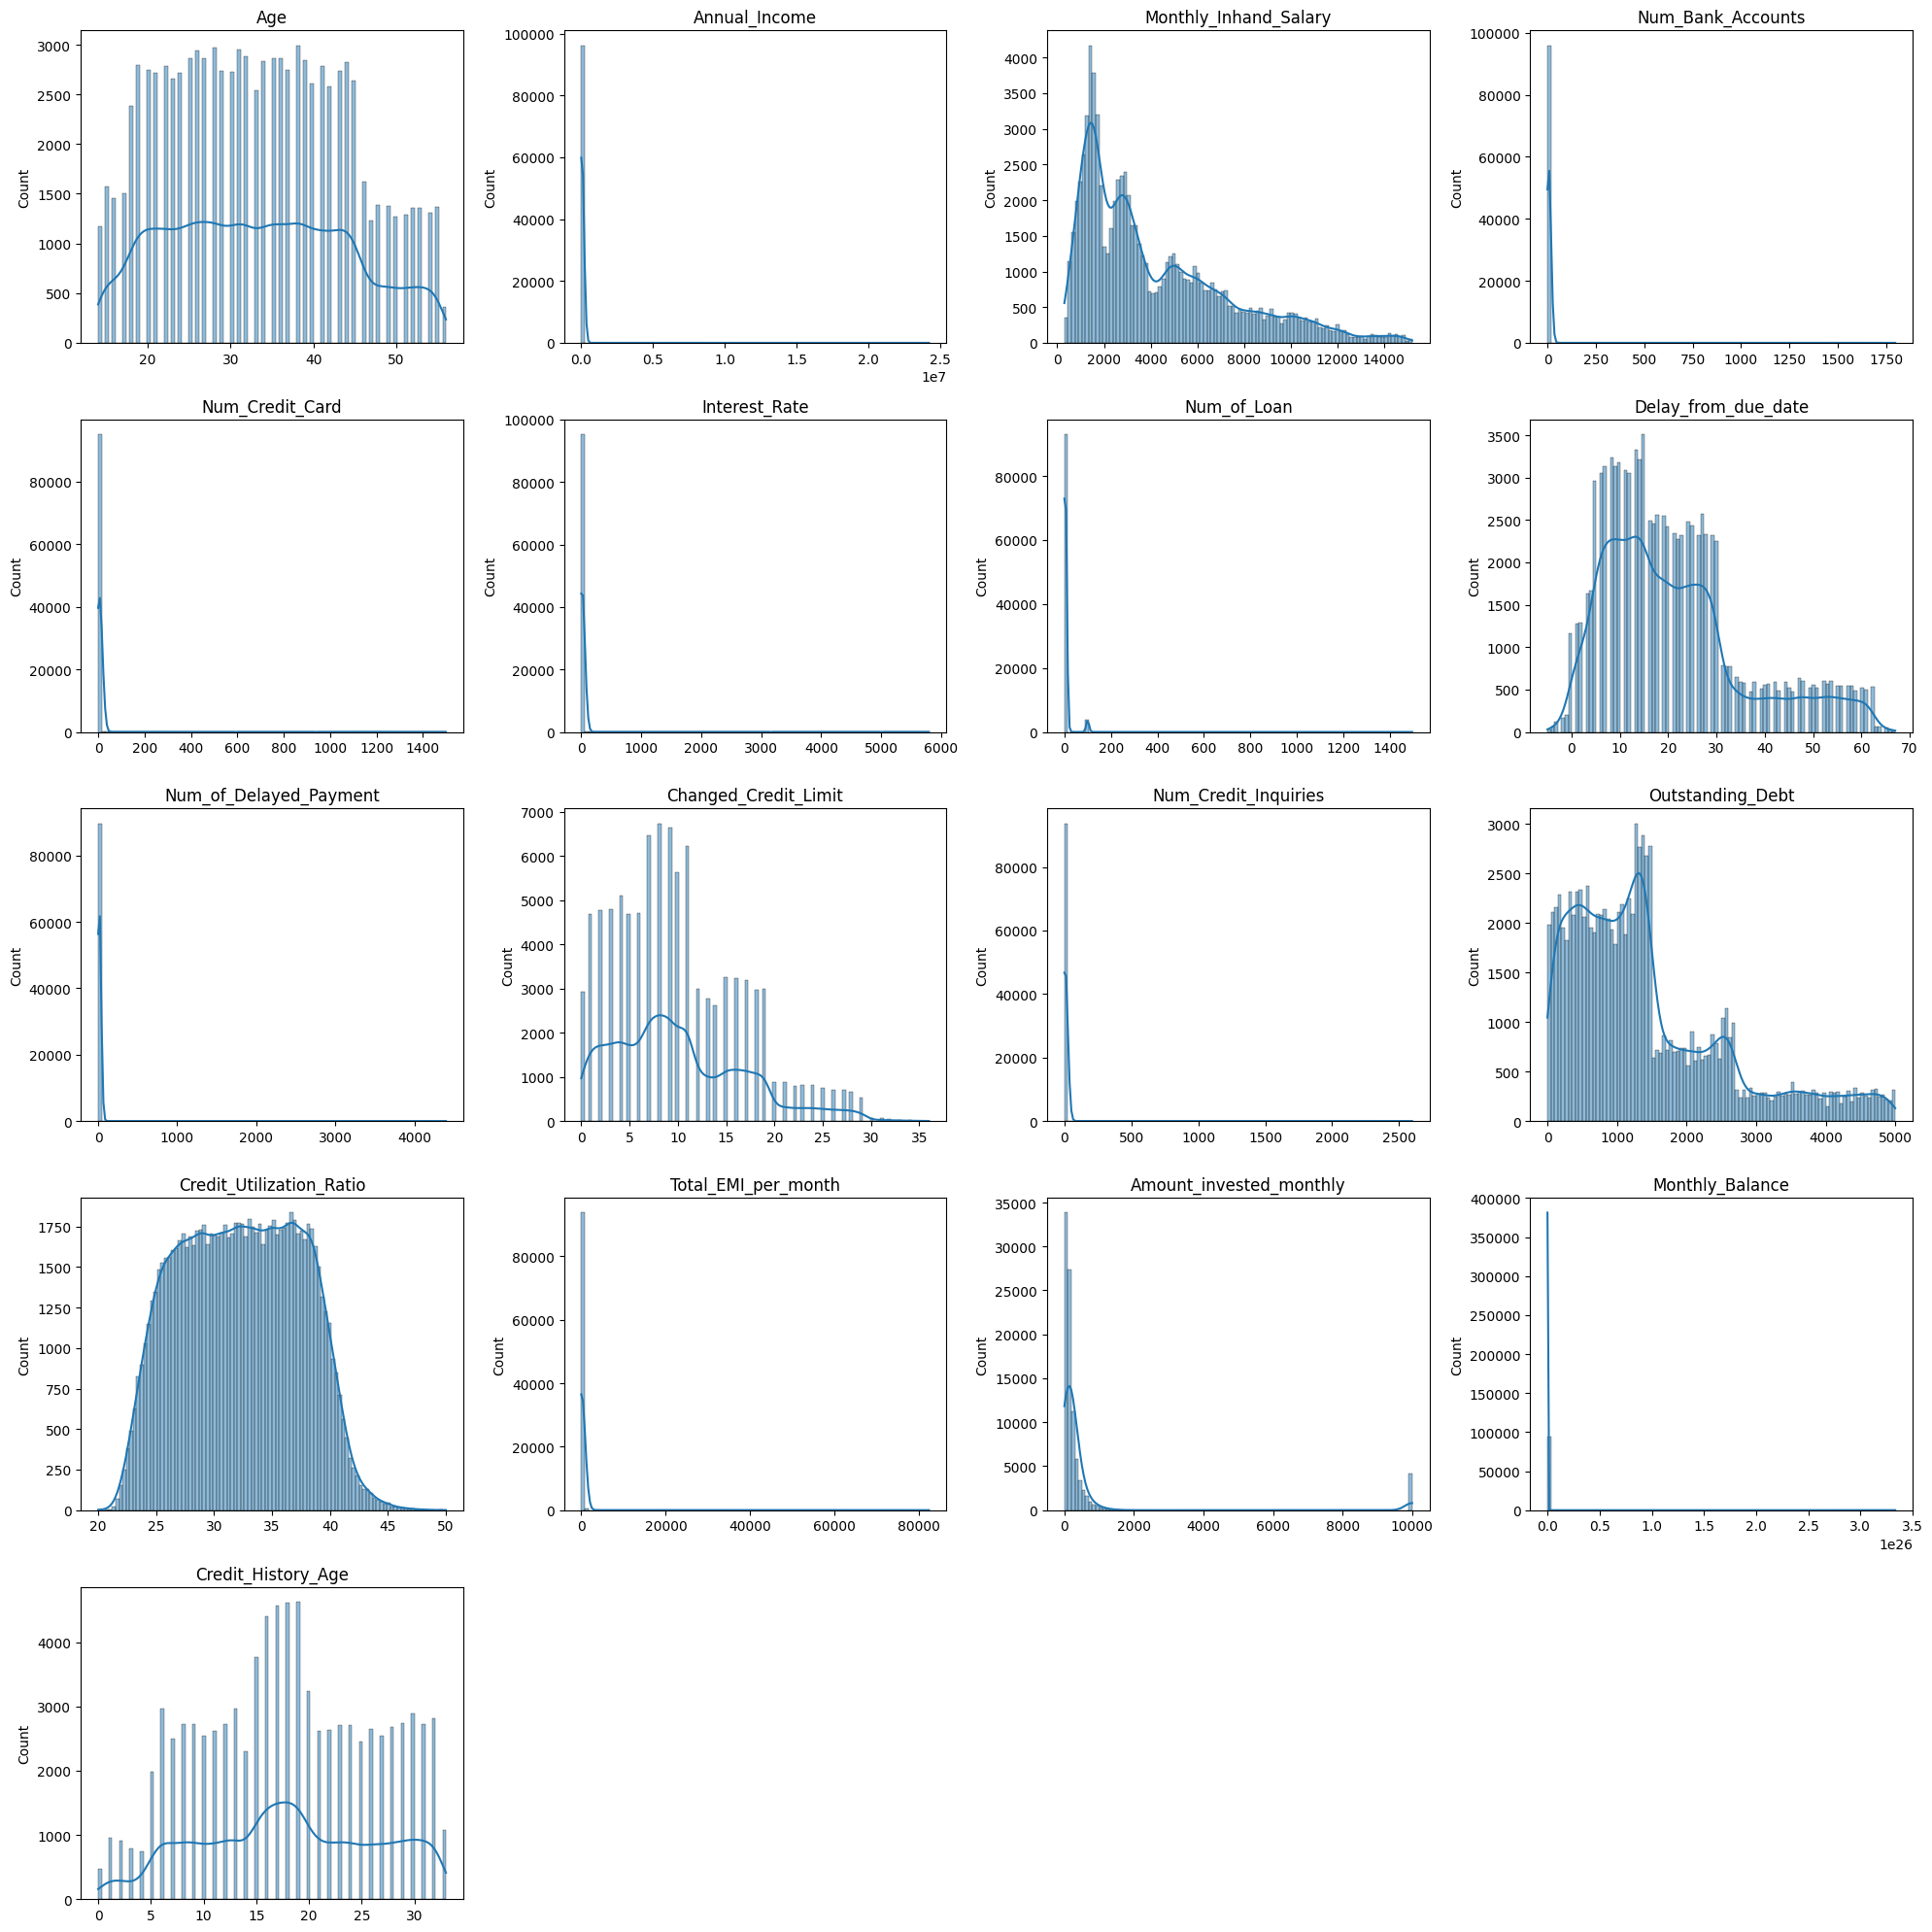

In [218]:
def plot_histograms(df, columns, rows=2, cols=3):

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i], bins=100)
            axes[i].set_title(col)
            axes[i].set_xlabel('')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_histograms(df, numerical, rows=5, cols=4)

### 2.4 Handling Outliers

For the Following 11 Features:
**Annual_Income**, **Num_Bank_Accounts**, **Num_Credit_Card**, **Interest_Rate**,  
**Num_of_Loan**, **Delay_from_due_date**, **Outstanding_Debt**
, **Total_EMI_per_month**, **Amount_invested_monthly**, **Num_Credit_Inquiries**  
,**Monthly_Balance**


Remove Outliers function
- The IQR method is a statistical technique used to detect and remove outliers based on how far values fall from the middle 50% of the data.

In [219]:
def Remove_Outliers(data , column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return outliers

Get Outliers function
- retrieve data that are too far below Q1 or too far above Q3.

In [220]:
def Check_Outliers(data , column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

1. Annual_Income Outliers

In [221]:
Check_Outliers(df , 'Annual_Income')['Annual_Income']

54       10909427
231       6515990
245        586359
361      18334118
368      19717385
           ...   
99664     5794377
99714    11712577
99721     8544730
99882    16884797
99945    10152115
Name: Annual_Income, Length: 2699, dtype: int64

In [222]:
df = Remove_Outliers(df , 'Annual_Income')

- Interpretation: The distribution of Annual_Income data has become more stable and realistic. Compared to the heavily skewed original version.
- The Standard credit score group has the highest frequency across almost all income levels.
- At the lower income ranges, the Poor credit score group appears more frequently than the Good group.
- As income increases, the proportion of Good credit score individuals rises relative to the Poor group
- Overall, the Good credit score group is the smallest group across all income levels, but it gradually increases with higher income levels.
- The distribution is right-skewed.

<Axes: xlabel='Annual_Income', ylabel='Count'>

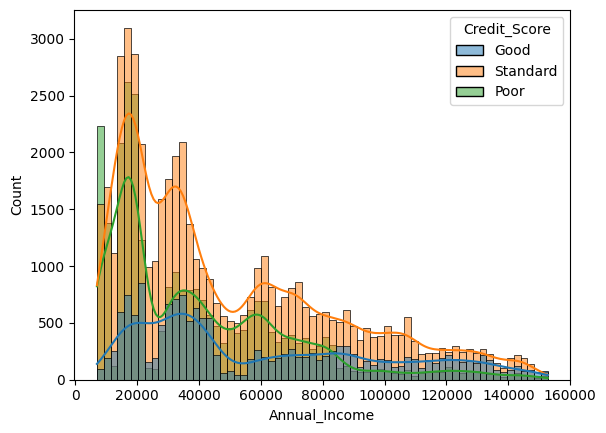

In [223]:
sns.histplot(data=df , x = df['Annual_Income'] , hue='Credit_Score' , kde=True)

2. Num_Bank_Accounts and Num_Credit_Card Outliers

- Drop all rows with more than 10 bank accounts or 0 bank accounts. 
- Drop all rows with more than 10 credit cards or 0 credit cards.

Unrealistic to have more than 10, as some rows reaches 1000 bank accounts and credit cards.

In [224]:
df.drop(df[(df['Num_Bank_Accounts']>10) | (df['Num_Bank_Accounts']==0)].index , axis=0 , inplace=True)
df.drop(df[(df['Num_Credit_Card']>10) | (df['Num_Credit_Card']==0)].index , axis=0 , inplace=True)

Absolute the negative numbers.

In [225]:
df['Num_Bank_Accounts'] = np.abs(df['Num_Bank_Accounts'])

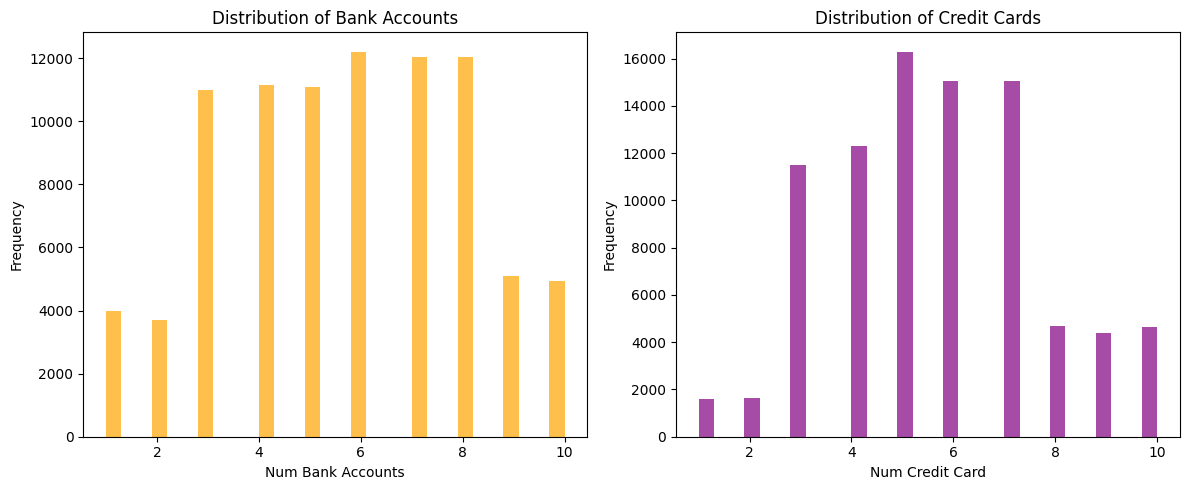

In [226]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].hist(df['Num_Bank_Accounts'], bins=30, alpha=0.7, color='orange')
axes[0].set_xlabel('Num Bank Accounts')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Bank Accounts')


axes[1].hist(df['Num_Credit_Card'], bins=30, alpha=0.7, color='purple')
axes[1].set_xlabel('Num Credit Card')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Credit Cards')


plt.tight_layout()
plt.show()

3. Interest_Rate Outliers
- Interest rate usually small values.
- Assuming no interest rate over 34%.

In [227]:
df['Interest_Rate'].unique()

array([   3,    6,    8, ..., 1347,  387, 5729], shape=(1557,))

In [228]:
df.loc[df['Interest_Rate'] > 34 , 'Interest_Rate' ] = np.nan

<Axes: xlabel='Interest_Rate', ylabel='Count'>

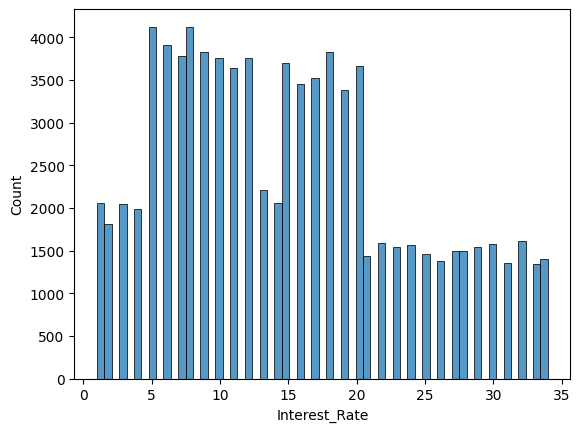

In [229]:
sns.histplot(df['Interest_Rate'])

In [230]:
df['Interest_Rate'].unique()

array([ 3.,  6.,  8.,  4.,  5., nan, 15.,  7., 12., 20.,  1., 14., 32.,
       16., 17., 10., 31., 25., 18., 19.,  9., 24., 13., 33., 11., 21.,
       29., 28., 30., 23., 34.,  2., 27., 26., 22.])

- Applying log transform (convert each value to ln(x)).
- Reduces skewness (makes distribution closer to normal).

<Axes: xlabel='Interest_Rate', ylabel='Density'>

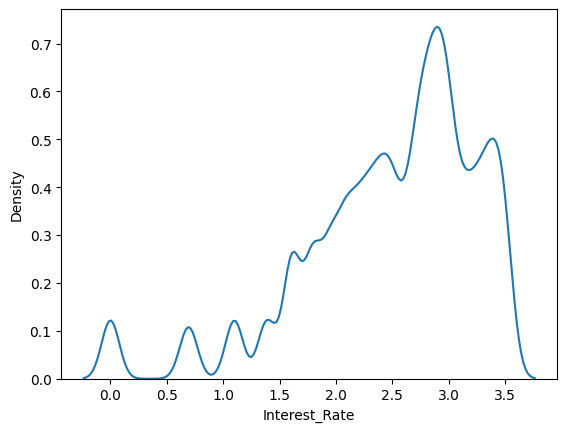

In [231]:
sns.kdeplot( np.log(df['Interest_Rate']))

- Converts interest rates to log scale.

In [232]:
df['Interest_Rate'] = np.log(df['Interest_Rate'])

In [233]:
df['Interest_Rate'].min()

np.float64(0.0)

<Axes: xlabel='Interest_Rate', ylabel='Count'>

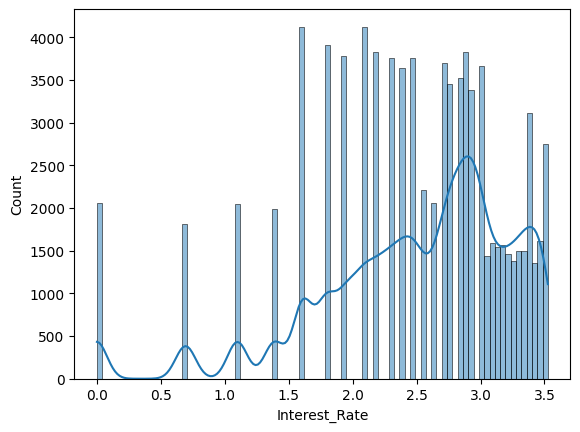

In [234]:
sns.histplot(df['Interest_Rate'] , kde=True)

4. Num_of_Loan Outliers

Drop if number of loans exceeded 10 or have 0 loans.

Drop rows with 0 loans keeps only customers who have credit history.


In [235]:
df.drop(df[(df['Num_of_Loan']>10) | (df['Num_of_Loan']==0)].index , axis=0 , inplace=True)

-100 loans is impossible

In [236]:
df.drop(df[df['Num_of_Loan'] == -100].index , axis=0 , inplace=True)

<Axes: xlabel='Num_of_Loan', ylabel='Count'>

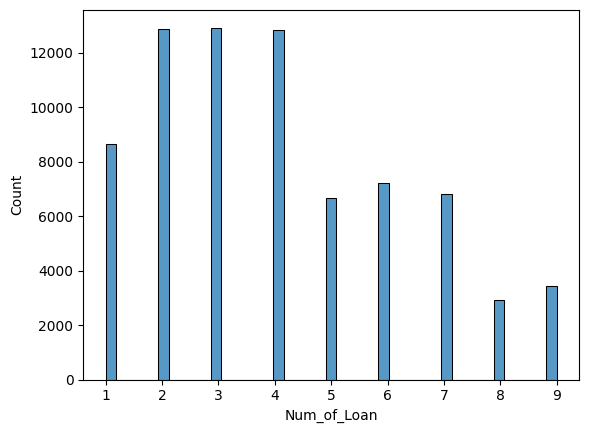

In [237]:
sns.histplot(df['Num_of_Loan'])

5. Delay_from_due_date (in days) Outliers

<Axes: xlabel='Delay_from_due_date', ylabel='Density'>

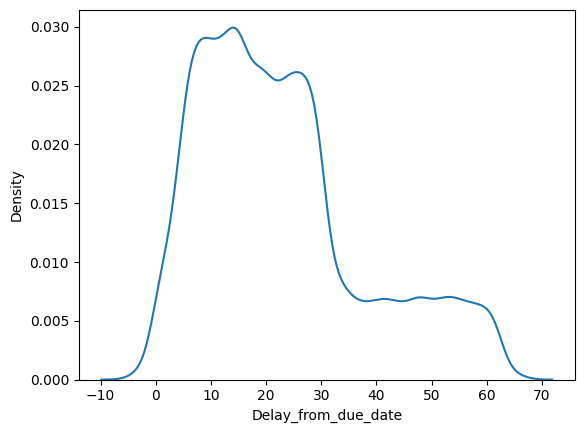

In [238]:
sns.kdeplot(df['Delay_from_due_date'])

Absolute the negative values.

In [239]:
df['Delay_from_due_date'] = np.abs(df['Delay_from_due_date'])

<Axes: xlabel='Delay_from_due_date', ylabel='Count'>

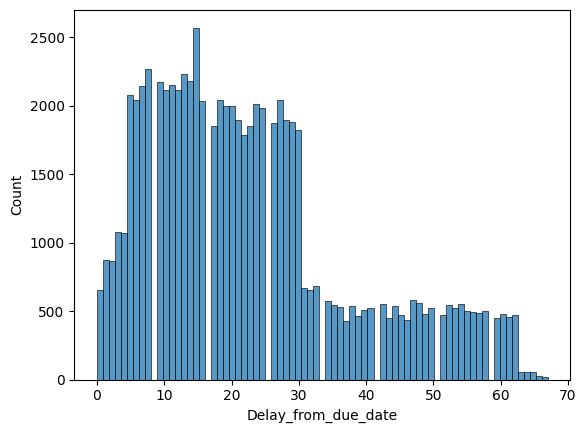

In [240]:
sns.histplot(df['Delay_from_due_date'])

Convert to months for easier interpretation. using // to approximate months.

In [241]:
df['Months_Delayed'] = (df['Delay_from_due_date'] // 30)

Drop all rows with delays over a month and a half (extreme delay/outlier).

In [242]:
df.drop(df[df['Months_Delayed']>1.5].index , axis=0 , inplace=True)

<Axes: xlabel='Months_Delayed', ylabel='Count'>

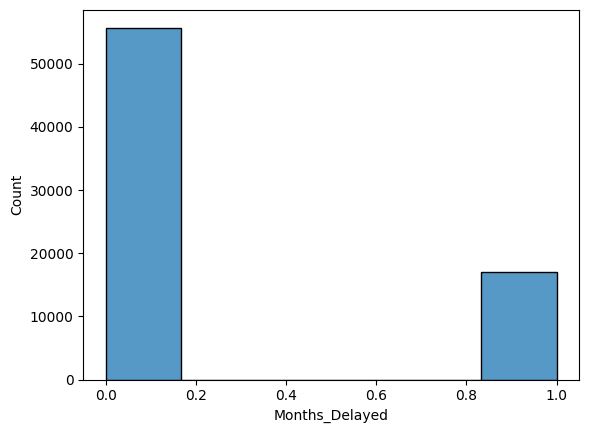

In [243]:
sns.histplot(data=df , x = 'Months_Delayed' , bins=6)

drop the delay in days.

In [244]:
df = df.drop('Delay_from_due_date', axis=1)

6. Num_of_Delayed_Payment Outliers.

Drop all with delayed payments over or equal 25 or in negative.
assuming not over 25 delayed payments per person

<Axes: xlabel='Num_of_Delayed_Payment', ylabel='Density'>

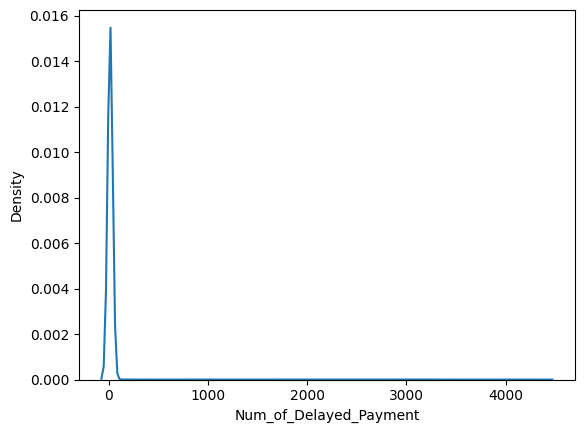

In [245]:
sns.kdeplot(df['Num_of_Delayed_Payment'])

In [246]:
#def cap_skewed(df, col, lower=0.01, upper=0.99):
    #lower_bound = df[col].quantile(lower)
    #upper_bound = df[col].quantile(upper)
    #df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    #return df


In [247]:
df.drop(df[(df['Num_of_Delayed_Payment']>=25) | (df['Num_of_Delayed_Payment']<0)].index, axis=0 , inplace=True)

<Axes: xlabel='Num_of_Delayed_Payment', ylabel='Count'>

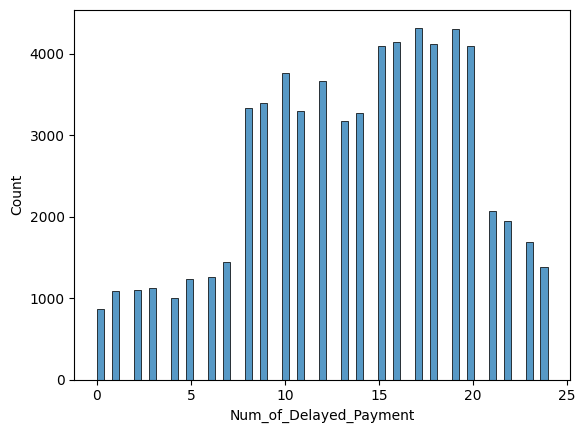

In [248]:
sns.histplot(df['Num_of_Delayed_Payment'])

7. Outstanding_Debt Outliers

Dropping these values is the best option, as capping the data would not reduce it that much.

<Axes: xlabel='Outstanding_Debt', ylabel='Density'>

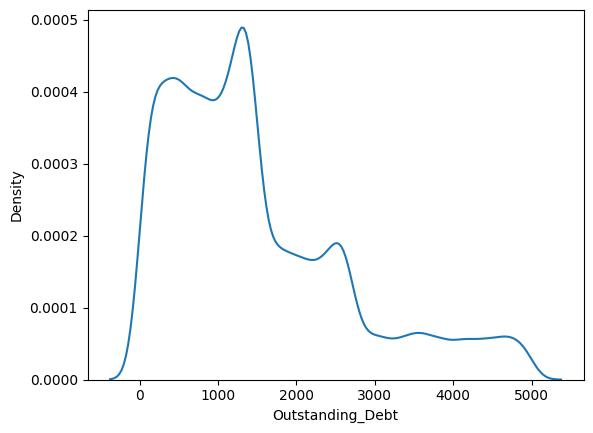

In [249]:
sns.kdeplot(df['Outstanding_Debt'])

In [250]:
df = df[df['Outstanding_Debt'] <= 2000]

<Axes: xlabel='Outstanding_Debt', ylabel='Count'>

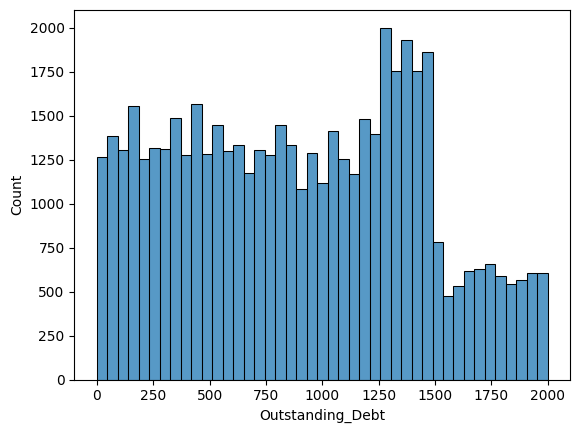

In [251]:
sns.histplot(df['Outstanding_Debt'])

8. Total_EMI_per_month Outliers

Represents the monthly EMI payments (in USD).

An EMI (Equated Monthly Instalment) payment is a fixed amount a borrower pays to a lender each month to repay a loan.

In [252]:
Check_Outliers(df , 'Total_EMI_per_month')['Total_EMI_per_month']

76      16,415.00
94      80,357.00
187     33,746.00
241     14,130.00
246      5,994.00
           ...   
99957      362.07
99958      362.07
99959      362.07
99970   75,011.00
99993   58,638.00
Name: Total_EMI_per_month, Length: 3530, dtype: float64

In [253]:
def replace_outliers_with_nan(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[column] = df[column].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)

    return df

In [254]:
#df=Remove_Outliers(df,'Total_EMI_per_month') #REMOVED A LOTTT
#df=cap_skewed(df,'Total_EMI_per_month')

Replace outliers with Nulls to be handled later.

In [255]:
def replace_outliers_with_nan(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[column] = df[column].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)

    return df

In [256]:
df = replace_outliers_with_nan(df, 'Total_EMI_per_month')

<Axes: xlabel='Total_EMI_per_month', ylabel='Density'>

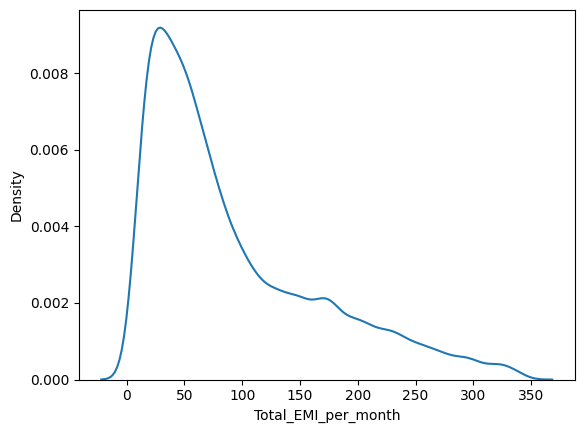

In [257]:
sns.kdeplot(df['Total_EMI_per_month'])

9. Amount_Invested_Monthly Outliers.

In [258]:
df['Amount_invested_monthly'] = np.log(df['Amount_invested_monthly'])

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

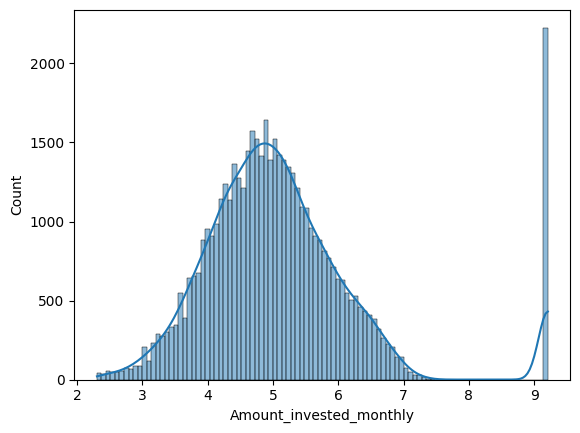

In [259]:
sns.histplot(df['Amount_invested_monthly'], kde=True)

In [260]:
df.drop(df[df['Amount_invested_monthly'] > 9].index , axis=0 , inplace= True)

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

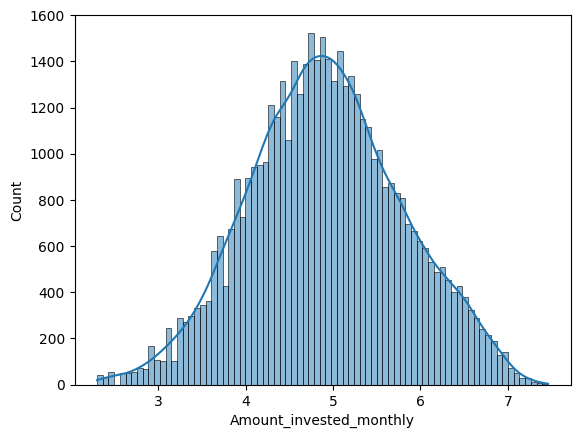

In [261]:
sns.histplot(df['Amount_invested_monthly'], kde=True)

10. Num_Credit_Inquiries Outliers.

<Axes: xlabel='Num_Credit_Inquiries', ylabel='Density'>

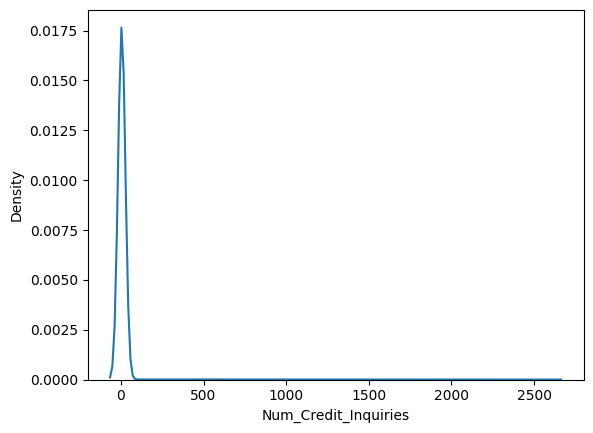

In [262]:
sns.kdeplot(df['Num_Credit_Inquiries'])

In [263]:
df = Remove_Outliers(df , 'Num_Credit_Inquiries')
#df['Num_Credit_Inquiries'] = np.log(df['Num_Credit_Inquiries'])

<Axes: xlabel='Num_Credit_Inquiries', ylabel='Count'>

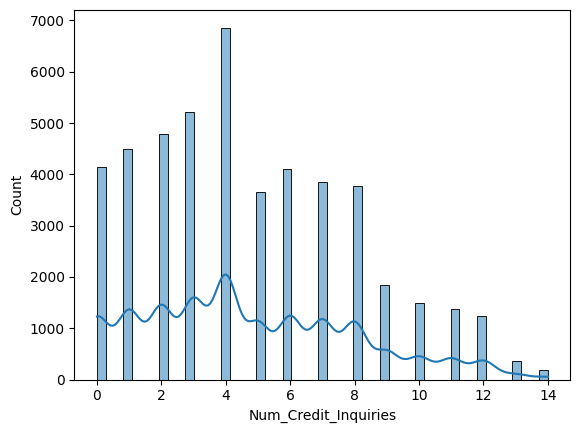

In [264]:
sns.histplot(df['Num_Credit_Inquiries'] , kde=True)

11. Monthly_Balance Outliers.

In [265]:
#df = cap_skewed(df , 'Monthly_Balance')
df = Remove_Outliers(df , 'Monthly_Balance')

<Axes: xlabel='Monthly_Balance', ylabel='Count'>

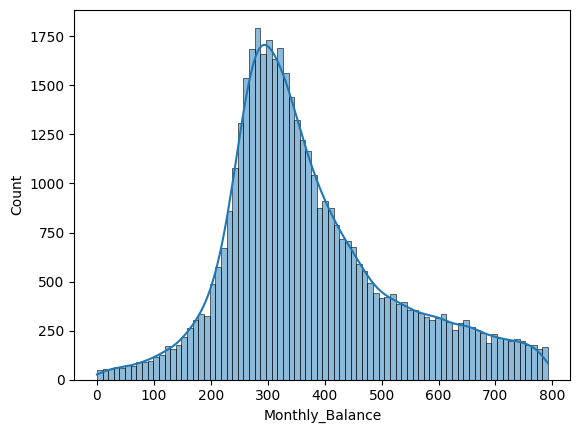

In [266]:
sns.histplot(df['Monthly_Balance'] , kde=True)

In [267]:
df.shape

(43365, 22)

### 2.5 Handling Nulls

In [268]:
df.isnull().mean()*100

Age                         0.00
Occupation                  0.00
Annual_Income               0.00
Monthly_Inhand_Salary      14.97
Num_Bank_Accounts           0.00
Num_Credit_Card             0.00
Interest_Rate               1.99
Num_of_Loan                 0.00
Num_of_Delayed_Payment      6.98
Changed_Credit_Limit        2.08
Num_Credit_Inquiries        0.00
Credit_Mix                  0.00
Outstanding_Debt            0.00
Credit_Utilization_Ratio    0.00
Credit_History_Age          9.07
Payment_of_Min_Amount       0.00
Total_EMI_per_month         6.56
Amount_invested_monthly     4.58
Payment_Behaviour           0.00
Monthly_Balance             0.00
Credit_Score                0.00
Months_Delayed              0.00
dtype: float64

- Mean imputation: works well for roughly symmetric distributions without extreme outliers. It preserves the average value of the column.
- Median imputation: is robust to outliers because it is the middle value. Features with skewed distributions or extreme outliers should use median, otherwise the imputed values would be unrealistically high or low.

In [269]:
columns_that_filling_mean = ['Num_of_Delayed_Payment' , 'Changed_Credit_Limit' ,
                             'Amount_invested_monthly' ,'Credit_History_Age']
columns_that_filling_median = ['Annual_Income' ,'Interest_Rate' , 'Total_EMI_per_month','Monthly_Balance']

Assuming Monthly_Inhand_Salary is Annual_Income/12.

Imputing with mean or median will not make sense as mean of monthly salary would be more than each row annual income.

In [270]:
# Fill missing Monthly_Inhand_Salary using Annual_Income / 12
df['Monthly_Inhand_Salary'] = df['Monthly_Inhand_Salary'].fillna(df['Annual_Income'] / 12)

In [271]:
for col in columns_that_filling_mean:
    df[col].fillna(df[col].mean() , inplace=True)

In [272]:
for col1 in columns_that_filling_median:
    df[col1].fillna(df[col1].median() , inplace=True)

- Inconsistent Format and Feature Extraction: 

Extract Spending_Level and Payment_Value from Payment_Behaviour (multicategorical). 

Remove underscores and meaningless values instead of imputation, because this will skew the data and give the data more outliers.

In [273]:
df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      10932
High_spent_Medium_value_payments     7796
Low_spent_Medium_value_payments      6190
High_spent_Small_value_payments      5203
High_spent_Large_value_payments      5156
Low_spent_Large_value_payments       4831
!@9#%8                               3257
Name: count, dtype: int64

In [274]:
df['Occupation'].value_counts()

Occupation
_______          3040
Lawyer           3008
Architect        2875
Entrepreneur     2758
Doctor           2742
Media_Manager    2738
Scientist        2720
Mechanic         2690
Engineer         2683
Teacher          2682
Musician         2664
Developer        2637
Writer           2600
Accountant       2549
Journalist       2543
Manager          2436
Name: count, dtype: int64

Lawyer is most frequent occupation.

In [275]:
#df['Occupation'] = df['Occupation'].replace("_______", 'Lawyer')

In [276]:
df['Occupation'].value_counts()

Occupation
_______          3040
Lawyer           3008
Architect        2875
Entrepreneur     2758
Doctor           2742
Media_Manager    2738
Scientist        2720
Mechanic         2690
Engineer         2683
Teacher          2682
Musician         2664
Developer        2637
Writer           2600
Accountant       2549
Journalist       2543
Manager          2436
Name: count, dtype: int64

In [277]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    21021
Good        11001
_            8770
Bad          2573
Name: count, dtype: int64

In [278]:
#df['Credit_Mix'] = df['Credit_Mix'].replace("_", df['Credit_Mix'].mode()[0])

In [279]:
#df['Payment_Behaviour'] = df['Payment_Behaviour'].replace("!@9#%8", df['Payment_Behaviour'].mode()[0])

In [280]:
df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      10932
High_spent_Medium_value_payments     7796
Low_spent_Medium_value_payments      6190
High_spent_Small_value_payments      5203
High_spent_Large_value_payments      5156
Low_spent_Large_value_payments       4831
!@9#%8                               3257
Name: count, dtype: int64

In [281]:
df = df[df['Payment_Behaviour'] != '!@9#%8']
df[['Spending_Level', 'Payment_Value']] = df['Payment_Behaviour'].str.split('_', n=1, expand=True)
df['Payment_Value'] = df['Payment_Value'].str.rsplit('_', n=1, expand=True)[0]
df['Payment_Value'] = df['Payment_Value'].str.rsplit('_', n=1, expand=True)[0] 
df['Payment_Value'] = df['Payment_Value'].str.replace('spent_', '')

In [282]:
df['Spending_Level']

0        High
1         Low
3         Low
4        High
6         Low
         ... 
98272    High
98274    High
98275    High
98276     Low
98277    High
Name: Spending_Level, Length: 40108, dtype: object

In [283]:
df['Payment_Value']

0         Small
1         Large
3         Small
4        Medium
6         Small
          ...  
98272    Medium
98274     Small
98275    Medium
98276     Small
98277    Medium
Name: Payment_Value, Length: 40108, dtype: object

In [284]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    19428
Good        10201
_            8106
Bad          2373
Name: count, dtype: int64

In [285]:
df['Payment_of_Min_Amount'].value_counts()

Payment_of_Min_Amount
Yes    19179
No     16089
NM      4840
Name: count, dtype: int64

function that removes remove any row with underscore

In [286]:
def remove_underscore_rows(df, column_name):

    filtered_df = df[~df[column_name].str.contains('_', na=False)]

    removed_rows = len(df) - len(filtered_df)
    print(f"{column_name} column removed {removed_rows} rows.")

    return filtered_df

In [287]:
categorical = ["Occupation","Credit_Mix", "Spending_Level","Payment_Value","Payment_of_Min_Amount"]

target = ["Credit_Score"]

In [288]:
for col in categorical:
    df = remove_underscore_rows(df, col)


Occupation column removed 5343 rows.
Credit_Mix column removed 7046 rows.
Spending_Level column removed 0 rows.
Payment_Value column removed 0 rows.
Payment_of_Min_Amount column removed 0 rows.


In [289]:
#df['Occupation'] = df['Occupation'].replace("_______", df['Occupation'].mode()[0])
#df['Credit_Mix'] = df['Credit_Mix'].replace("_", df['Credit_Mix'].mode()[0])

In [290]:
replace = {"NM": "No"}
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace(replace)

In [291]:
df["Payment_of_Min_Amount"].value_counts()

Payment_of_Min_Amount
No     14566
Yes    13153
Name: count, dtype: int64

In [292]:
df.isnull().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Months_Delayed              0
Spending_Level              0
Payment_Value               0
dtype: int64

Removes the old index entirely.

Creates a new index: 0, 1, 2, 3, ...

Useful after:
 - Dropping rows
 - Concatenating DataFrames
 - Filtering
 - Removing outliers

In [293]:
df = df.reset_index(drop=True)

### 3. Data Cleaning Results

Distribution of Categorical Features.

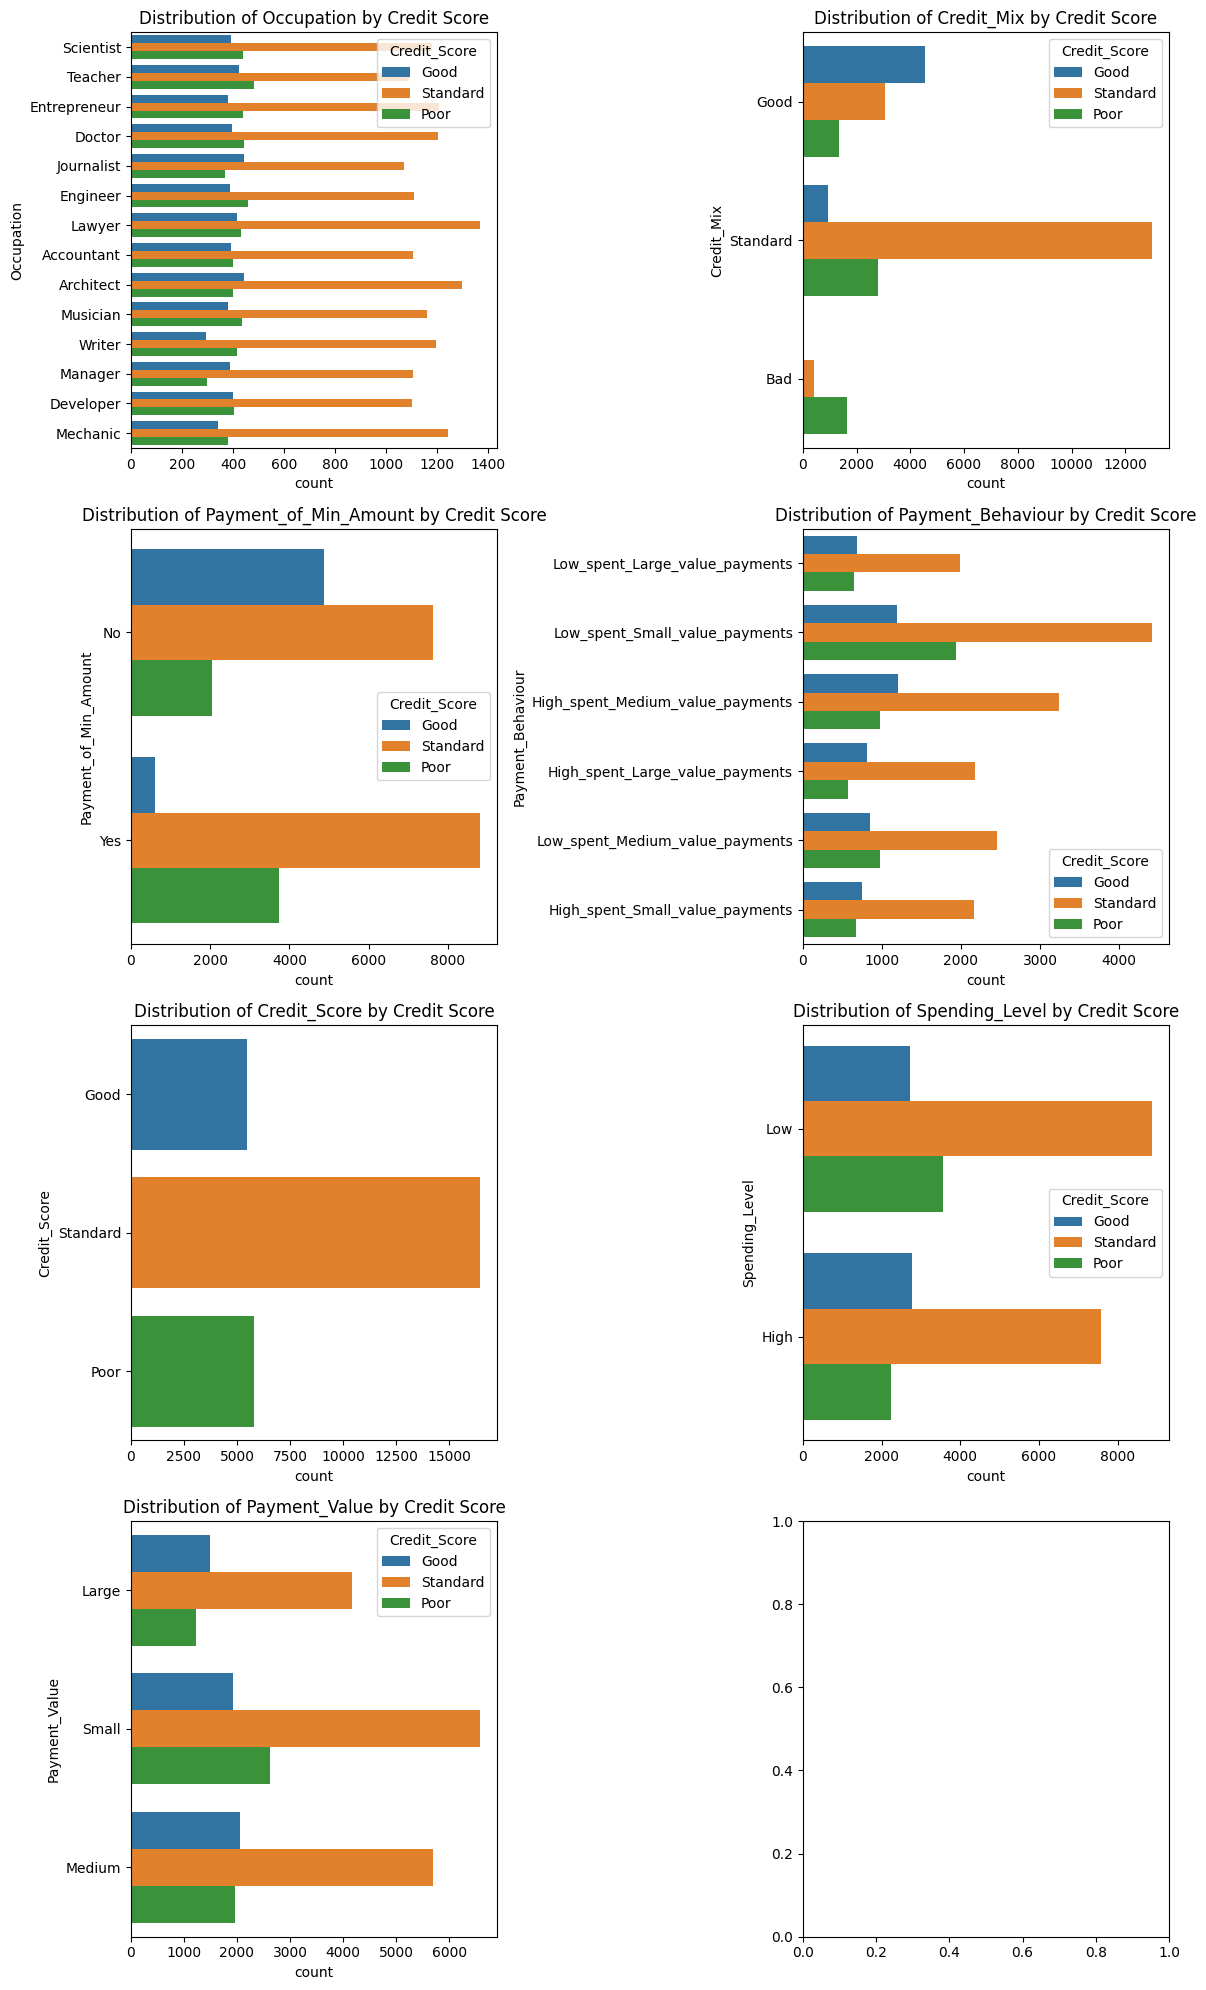

In [294]:
cat_cols = df.select_dtypes('O').columns


n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()


for i, col in enumerate(cat_cols):
    sns.countplot(y=df[col], hue=df['Credit_Score'], ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Credit Score')


plt.tight_layout()
plt.show()


Distribution of Numerical Features.

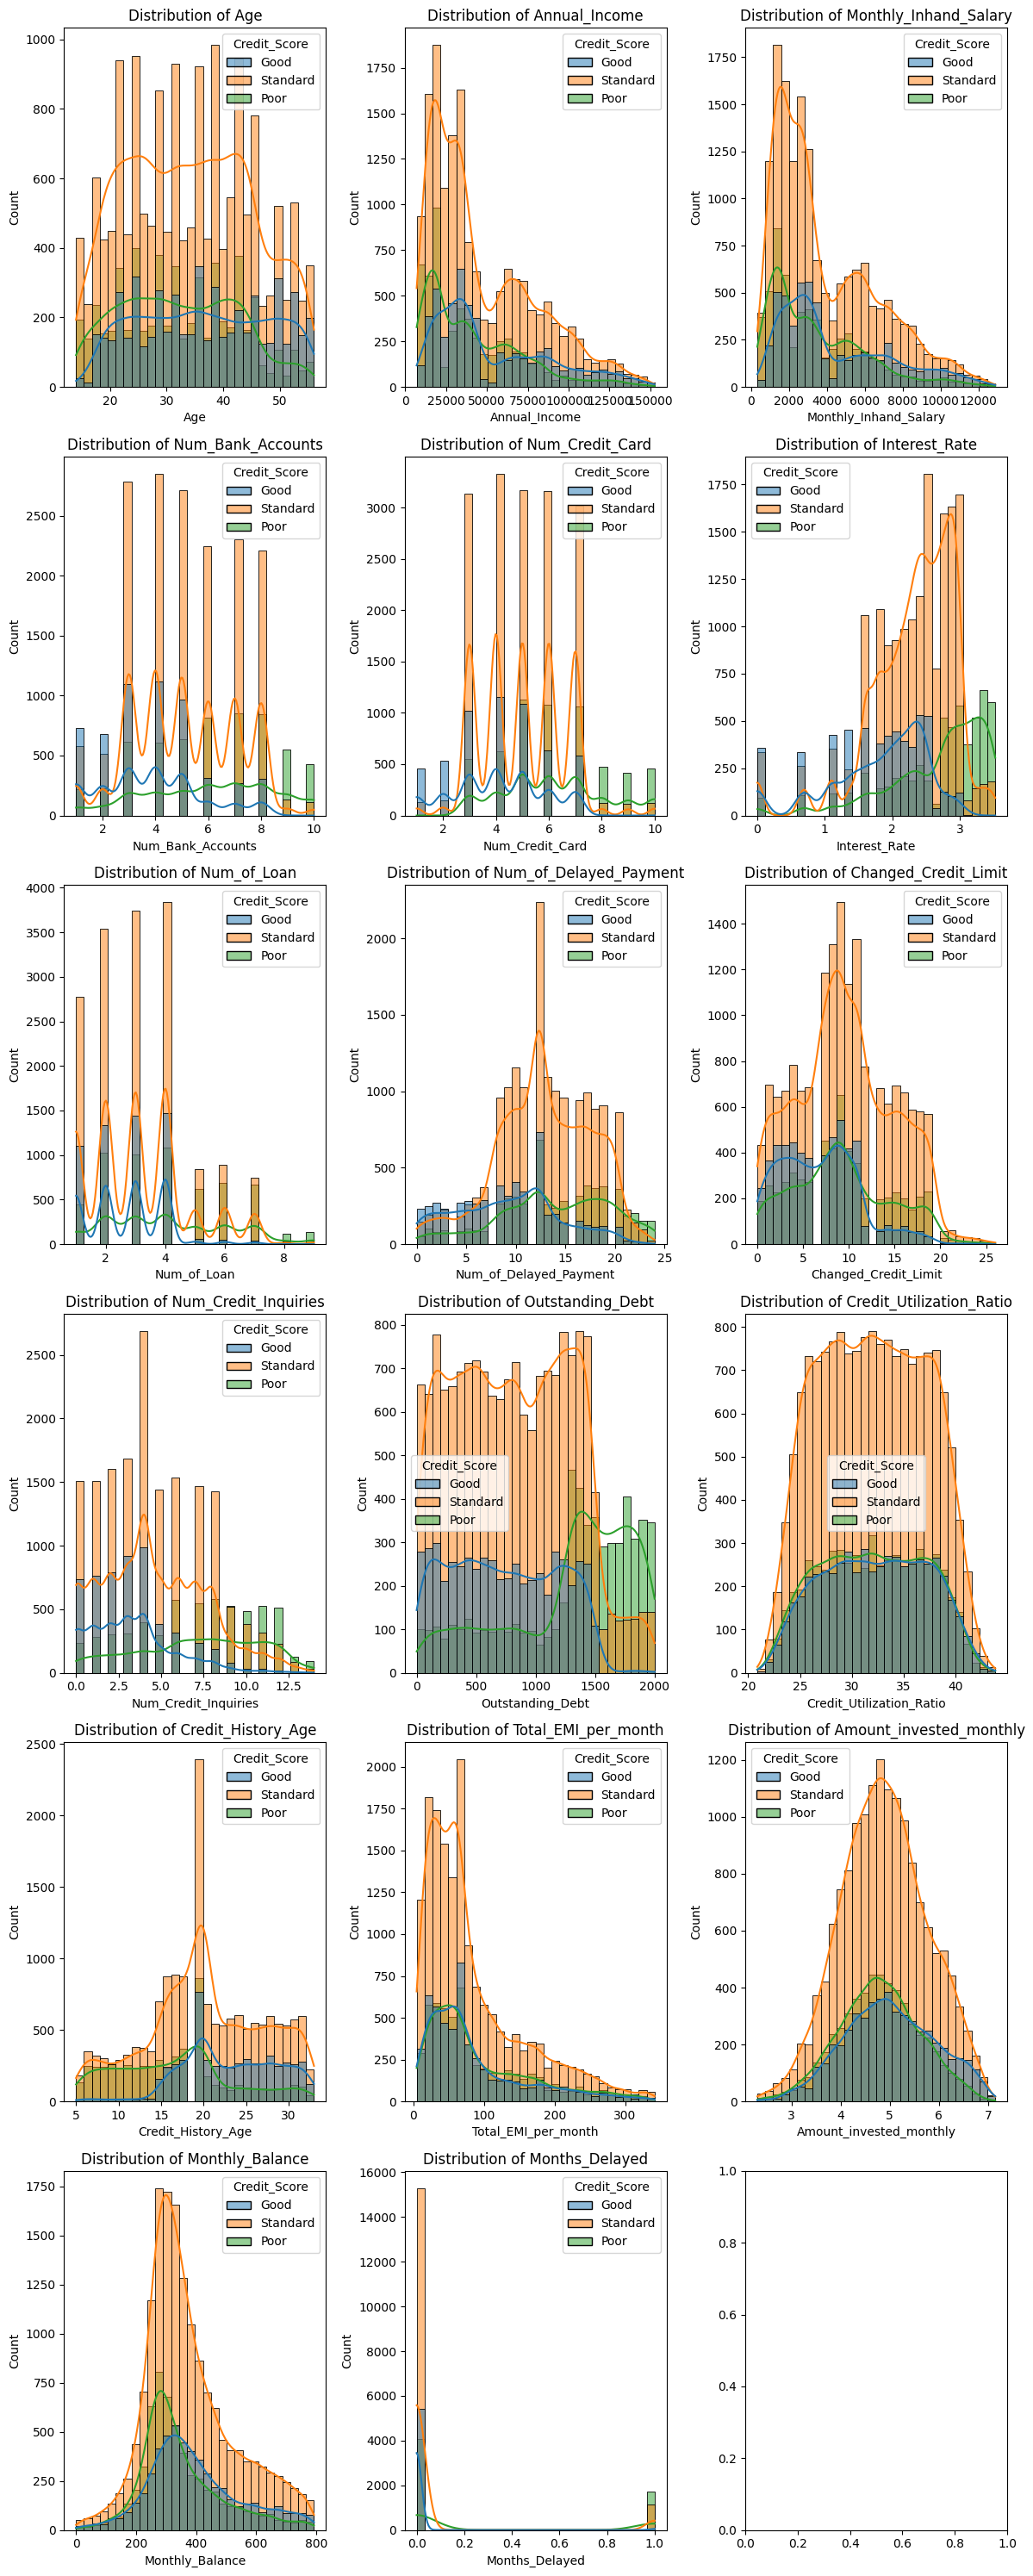

In [295]:
num_cols = df.select_dtypes('number').columns

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue=df['Credit_Score'], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


plt.tight_layout()
plt.show()



### 4. Data Encoding

- Binary encoding reduces the number of columns to log2(12) ≈ 4 columns.
Each new column is a binary digit representing the category

In [296]:
be = BinaryEncoder()

df_binary = be.fit_transform(df['Occupation'])

- Ordinal Encoder: Converts categorical features with an inherent order into numeric values.

In [297]:
credit_mix_order = ['Bad', 'Standard', 'Good']
credit_score_order = ['Poor', 'Standard', 'Good']
payment_behaviour_order = [
    'Low_spent_Small_value_payments',
    'Low_spent_Medium_value_payments',
    'Low_spent_Large_value_payments',
    'High_spent_Small_value_payments',
    'High_spent_Medium_value_payments',
    'High_spent_Large_value_payments'
]

ord = OrdinalEncoder(categories=[credit_mix_order , credit_score_order ,payment_behaviour_order ])

df[['Credit_Mix' , 'Credit_Score' , 'Payment_Behaviour']] = ord.fit_transform(df[['Credit_Mix' , 'Credit_Score', 'Payment_Behaviour']])


Encode Yes and No to 0 and 1.

In [298]:
mapper_Payment_of_Min_Amount  = {
    'Yes' : 1,
    'No' : 0
}

df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map(mapper_Payment_of_Min_Amount)

- Use One Hot Encoding, for nominal categories with no order.
- Use Label Encoding to not use the ordinal meaning.

In [299]:
#ohe = OneHotEncoder(sparse_output=False , drop='first')
#col = ['Spending_Level' , 'Payment_Value']

#df_ohe = pd.DataFrame(ohe.fit_transform(df[col]) , columns=ohe.get_feature_names_out())

In [300]:
from sklearn.preprocessing import LabelEncoder

col = ['Spending_Level', 'Payment_Value']

 #Initialize LabelEncoder
le = LabelEncoder()

 #Apply label encoding to each column
for c in col:
    df[c] = le.fit_transform(df[c])



In [301]:
#drop_to_encode = ['Spending_Level' , 'Payment_Value' , 'Occupation']
drop_to_encode = ['Occupation']

In [302]:
#df = pd.concat([df, df_binary , df_ohe] , axis=1).drop(drop_to_encode , axis = 1)
df = pd.concat([df, df_binary] , axis=1).drop(drop_to_encode , axis = 1)

In [ ]:
df

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Months_Delayed,Spending_Level,Payment_Value,Occupation_0,Occupation_1,Occupation_2,Occupation_3
0,23,19114,"1,592.83",3,4,1.10,4,12.34,11.00,4.00,2.00,809,31.94,19.93,0,49.57,4.77,2.00,284.00,2.00,0,1,0,0,0,0,1
1,23,19114,"1,592.83",3,4,1.10,4,4.00,6.00,4.00,2.00,809,31.38,22.00,0,49.57,5.29,0.00,223.00,2.00,0,1,2,0,0,0,1
2,23,19114,"1,824.84",3,4,1.10,4,12.34,11.00,4.00,2.00,809,24.80,22.00,0,49.57,3.71,4.00,341.00,2.00,0,0,1,0,0,0,1
3,23,19114,"1,824.84",3,4,1.10,4,8.00,11.00,4.00,2.00,809,22.54,22.00,0,49.57,5.18,0.00,244.00,2.00,0,1,2,0,0,0,1
4,23,19114,"1,824.84",3,4,1.10,4,6.00,11.00,4.00,2.00,809,23.93,19.93,0,49.57,3.18,4.00,358.00,1.00,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27714,39,120009,"10,242.78",5,1,1.95,4,1.00,6.00,0.00,2.00,446,37.37,28.00,0,230.53,5.65,4.00,758.00,1.00,0,0,1,0,0,0,1
27715,40,120009,"10,242.78",5,1,1.95,4,0.00,6.00,0.00,2.00,446,33.62,29.00,0,230.53,5.68,4.00,749.00,1.00,0,0,1,0,0,0,1
27716,40,120009,"10,242.78",5,1,1.95,4,3.00,6.00,0.00,2.00,446,40.49,29.00,0,230.53,-inf,3.00,460.00,1.00,0,0,2,0,0,0,1
27717,24,59868,"5,111.08",4,7,2.20,4,10.00,4.00,4.00,2.00,417,31.70,28.00,0,104.62,5.60,3.00,395.00,1.00,0,0,2,0,1,1,1


In [304]:
df.to_csv('cleaned_train.csv', index=False)

The data is ML ready.